# Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Importing Deep Learning Libraries

from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Input,Dropout,GlobalAveragePooling2D,Flatten,Conv2D,BatchNormalization,Activation,MaxPooling2D
from keras.models import Model,Sequential
from keras.optimizers import Adam,SGD,RMSprop

# Displaying Images

In [2]:
picture_size = 48
folder_path = "C:/Users/Ashritha/Desktop/Emotion_Detection_CNN-main/Emotion_Detection_CNN-main/input/"

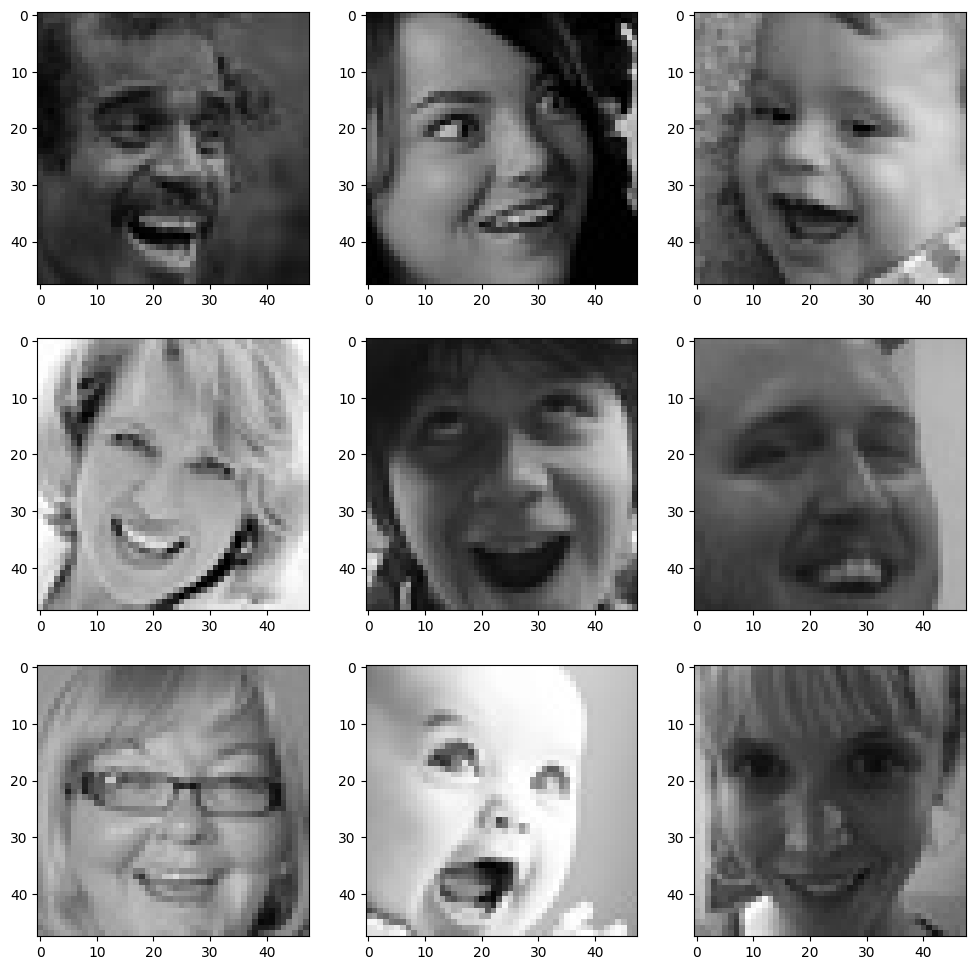

In [3]:
expression = 'happy'

plt.figure(figsize= (12,12))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)
    img = load_img(folder_path+"train/"+expression+"/"+
                  os.listdir(folder_path + "train/" + expression)[i], target_size=(picture_size, picture_size))
    plt.imshow(img)   
plt.show()

# Making Training and Validation Data

In [4]:
batch_size  = 128

datagen_train  = ImageDataGenerator(rescale=1./255)
datagen_val = ImageDataGenerator(rescale=1./255)

train_set = datagen_train.flow_from_directory(folder_path+"train",
                                              target_size = (48,48),
                                              color_mode = "grayscale",
                                              batch_size=32,
                                              class_mode='sparse',
                                              shuffle=True)


test_set = datagen_val.flow_from_directory(folder_path+"validation",
                                              target_size = (48,48),
                                              color_mode = "grayscale",
                                              batch_size=32,
                                              class_mode='sparse',
                                              shuffle=False)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Model Building

In [5]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Number of output classes
no_of_classes = 7

# ✅ Model architecture (simplified for CPU)
model = Sequential()

# Input layer
model.add(Input(shape=(48, 48, 1)))

# 1st CNN layer
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd CNN layer
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd CNN layer
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected layers
model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(no_of_classes, activation='softmax'))

# ✅ Optimizer and compilation
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks
checkpoint = ModelCheckpoint("./model.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)
reduce_learningrate = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_delta=0.0001)
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

# ✅ Data preprocessing (example using ImageDataGenerator)
datagen = ImageDataGenerator(rescale=1./255)
batch_size = 32
epochs = 30  # Let EarlyStopping handle early exit

# Example usage (replace X_train, y_train with your actual data)
# train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)
# model.fit(train_generator, epochs=epochs, validation_data=(X_val, y_val), callbacks=callbacks_list)

# ✅ Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 684,935 (2.61 MB)

 Trainable params: 684,231 (2.61 MB)

 Non-trainable params: 704 (2.75 KB)

# Fitting the Model with Training and Validation Data 

In [6]:
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(train_set,
                                steps_per_epoch=train_set.n//train_set.batch_size,
                                epochs=epochs,
                                validation_data = test_set,
                                validation_steps = test_set.n//test_set.batch_size,
                                callbacks=callbacks_list
                                )

Epoch 1/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.2254 - loss: 2.0383
Epoch 1: val_accuracy improved from None to 0.37305, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 768s 846ms/step - accuracy: 0.2697 - loss: 1.8993 - val_accuracy: 0.3730 - val_loss: 1.6346 - learning_rate: 1.0000e-04
Epoch 2/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 3:01 203ms/step - accuracy: 0.3438 - loss: 1.6897

C:\Users\Ashritha\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.37305 to 0.37430, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.3438 - loss: 1.6897 - val_accuracy: 0.3743 - val_loss: 1.6342 - learning_rate: 1.0000e-04
Epoch 3/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.3343 - loss: 1.7077
Epoch 3: val_accuracy improved from 0.37430 to 0.41629, saving model to ./model.h5


...

897/897 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4375 - loss: 1.4338 - val_accuracy: 0.5307 - val_loss: 1.2529 - learning_rate: 1.0000e-04
Epoch 21/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.5242 - loss: 1.2631
Epoch 21: val_accuracy did not improve from 0.53069
897/897 ━━━━━━━━━━━━━━━━━━━━ 216s 240ms/step - accuracy: 0.5215 - loss: 1.2678 - val_accuracy: 0.5257 - val_loss: 1.2359 - learning_rate: 1.0000e-04
Epoch 22/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:50 190ms/step - accuracy: 0.6562 - loss: 1.0371
Epoch 22: val_accuracy did not improve from 0.53069
897/897 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.6562 - loss: 1.0371 - val_accuracy: 0.5266 - val_loss: 1.2320 - learning_rate: 1.0000e-04
Epoch 23/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5220 - loss: 1.2557
Epoch 23: val_accuracy improved from 0.53069 to 0.53585, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 262s 292ms/step - accuracy: 0.5251 - loss: 1.2504 - val_accuracy: 0.5359 - val_loss: 1.2175 - learning_rate: 1.0000e-04
Epoch 24/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 3:04 206ms/step - accuracy: 0.5000 - loss: 1.2621
Epoch 24: val_accuracy did not improve from 0.53585
897/897 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5000 - loss: 1.2621 - val_accuracy: 0.5357 - val_loss: 1.2188 - learning_rate: 1.0000e-04
Epoch 25/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5323 - loss: 1.2290
Epoch 25: val_accuracy improved from 0.53585 to 0.54171, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 264s 248ms/step - accuracy: 0.5331 - loss: 1.2326 - val_accuracy: 0.5417 - val_loss: 1.2022 - learning_rate: 1.0000e-04
Epoch 26/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 3:04 206ms/step - accuracy: 0.4062 - loss: 1.4679
Epoch 26: val_accuracy did not improve from 0.54171
897/897 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4062 - loss: 1.4679 - val_accuracy: 0.5416 - val_loss: 1.2024 - learning_rate: 1.0000e-04
Epoch 27/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5390 - loss: 1.2162
Epoch 27: val_accuracy improved from 0.54171 to 0.55148, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 216s 241ms/step - accuracy: 0.5371 - loss: 1.2189 - val_accuracy: 0.5515 - val_loss: 1.1847 - learning_rate: 1.0000e-04
Epoch 28/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:56 197ms/step - accuracy: 0.4688 - loss: 1.2087
Epoch 28: val_accuracy improved from 0.55148 to 0.55162, saving model to ./model.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.4688 - loss: 1.2087 - val_accuracy: 0.5516 - val_loss: 1.1870 - learning_rate: 1.0000e-04
Epoch 29/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5454 - loss: 1.1958
Epoch 29: val_accuracy did not improve from 0.55162
897/897 ━━━━━━━━━━━━━━━━━━━━ 243s 241ms/step - accuracy: 0.5464 - loss: 1.1992 - val_accuracy: 0.5442 - val_loss: 1.2014 - learning_rate: 1.0000e-04
Epoch 30/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:57 198ms/step - accuracy: 0.5625 - loss: 1.0670
Epoch 30: val_accuracy did not improve from 0.55162

Epoch 30: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
897/897 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5625 - loss: 1.0670 - val_accuracy: 0.5414 - val_loss: 1.2049 - learning_rate: 1.0000e-04
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 27.


# Plotting Accuracy & Loss

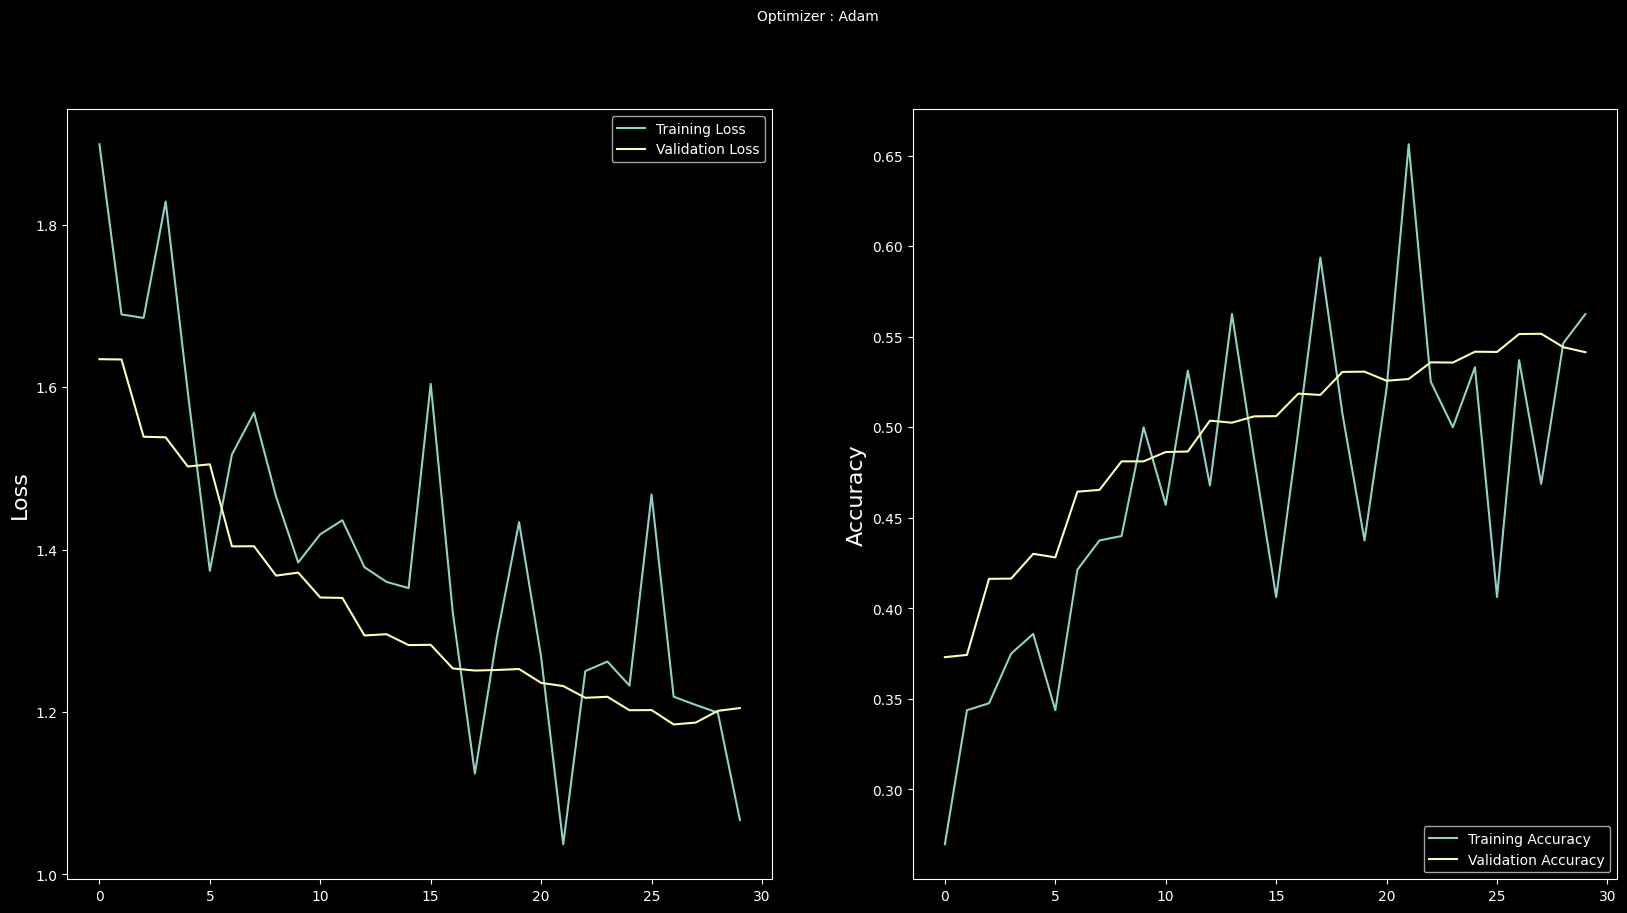

In [8]:
plt.style.use('dark_background')

plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : Adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()